In [1]:
import sys, os
sys.path.append(os.path.abspath(os.path.join('..')))
print(sys.path)

from BPMN.optimization import *
torch.set_default_dtype(torch.float64)
from libSOGAtruncate import truncate
import time

import torch
from torch.distributions import Normal, Categorical
import math

import BPMN.data_generating_process as dgp
import BPMN.helper_plots as hp
import matplotlib.pyplot as plt
import numpy as np


['/home/rdoz/miniconda3/envs/myenv/lib/python313.zip', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13/lib-dynload', '', '/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages', '/home/rdoz/PhD/DeGAS/src']


/home/rdoz/miniconda3/envs/myenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
compiledFile=compile2SOGA('programs/parallel.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

params = {
    'mu0':  1.,     # START
    'mu1':  60.,    # A_SUBMITTED
    'mu2':  60.,    # A_PARTLYSUBMITTED
    'mu3':  900.,   # W_Assess_fraud
    'mu4':  1200.,  # W_Fix_incomplete_submission
    'mu5':  60.,    # A_PREACCEPTED
    'mu6':  900.,   # W_Complete_preaccepted_appl
    'mu7':  60.,    # A_ACCEPTED
    'mu8':  60.,    # A_FINALIZED
    'mu9':  60.,    # O_SELECTED
    'mu10': 60.,    # O_CREATED
    'mu11': 60.,    # O_SENT
    'mu12': 600.,   # W_Call_after_offer
    'mu13': 60.,    # O_SENT_BACK
    'mu14': 900.,   # W_Call_missing_information
    'mu15': 1200.,  # W_Assess_application
    'mu16': 60.,    # O_CANCELLED
    'mu17': 60.,    # A_CANCELLED
    'mu18': 60.,    # A_DECLINED
    'mu19': 60.,    # O_DECLINED
    'mu20': 60.,    # O_ACCEPTED
    'mu21': 60.,    # A_APPROVED
    'mu22': 60.,    # A_REGISTERED
    'mu23': 60.,    # A_ACTIVATED
    'mu24': 1.,     # END

    'p0':  0.8,
    'p1':  0.3,
    'p2':  0.3,
    'p3':  0.8,
    'p4':  0.8,
    'p5':  0.7,
    'p6':  0.2,
    'p7':  0.8,
    'p8':  0.2,
    'p9':  0.4,
    'p10': 0.2,
    'p11': 0.7,
    'p12': 0.8,
    'p13': 0.2,
    'p14': 0.4,
    'p15': 0.8
}

for key in params:
    params[key] = params[key] ** 0.5

params_dict = initialize_params(params)
# computes SOGA output
output_dist = start_SOGA(cfg, params_dict)

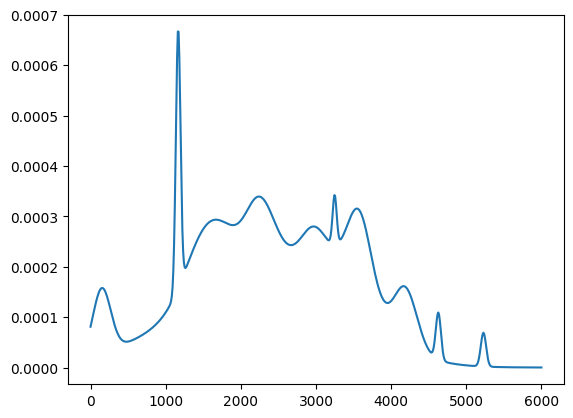

In [3]:
xs, pdf = hp.evaluate_marginal(output_dist, 't', 0, 6000, 600)
plt.plot(xs.numpy(), pdf.numpy())

In [13]:
output_dist.gm.mu

tensor([[ 8.3533e+00,  1.0591e+01,  1.0591e+01,  ..., -2.5991e+01,
         -1.5238e+01, -1.5801e+01],
        [ 8.3533e+00,  1.0591e+01,  1.0591e+01,  ..., -1.2756e+01,
         -8.4302e+00, -8.7050e+00],
        [ 8.3533e+00,  1.0591e+01,  1.0591e+01,  ...,  4.5753e+01,
         -1.5349e+01, -1.5199e+01],
        ...,
        [ 8.3533e+00,  1.0591e+01,  1.0591e+01,  ...,  9.1494e+01,
          8.7051e+01,  8.5153e+01],
        [ 8.3533e+00,  1.0591e+01,  1.0591e+01,  ...,  7.6090e+01,
          8.7119e-02,  8.7686e-02],
        [ 8.3533e+00,  1.0591e+01,  1.0591e+01,  ...,  1.3420e+02,
          1.3057e+02,  1.2863e+02]], grad_fn=<IndexBackward0>)

In [15]:
loss = lambda output_dist: -output_dist.gm.marg_pdf(torch.tensor([400.]), output_dist.var_list.index('t'))
print(loss(output_dist))

tensor([[-1.0336e-23]], grad_fn=<NegBackward0>)


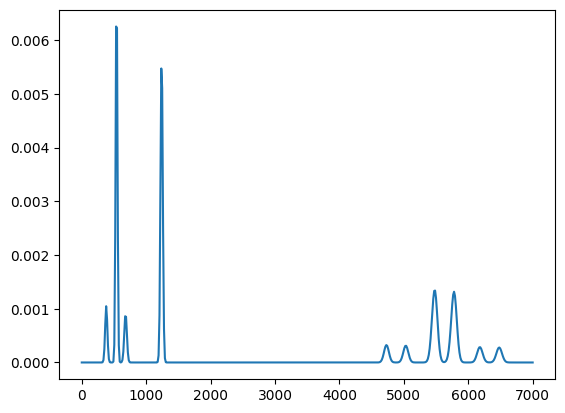

In [7]:
params = {
    'mu0':  40.,
    'mu1':  500.,
    'mu2':  700.,
    'mu3':  300.,
    'mu4':  40.,
    'mu5':  300.,
    'mu6':  500.,
    'mu7':  500.,
    'mu8':  350.,
    'mu9':  200.,
    'mu10': 700.,
    'mu11': 350.,
    'mu12': 200.,
    'mu13': 800.,   # ↓ big reduction here
    'mu14': 350.,
    'mu15': 200.,
    'mu16': 200.,
    'mu17': 350.,
    'mu18': 700.,
    'mu19': 200.,
    'mu20': 200.,

    'p0': 0.5,  # after Create Purchase Requisition -> Analyze Purchase Requisition
    'p1': 0.5,  # after Analyze Purchase Requisition -> Amend Purchase Requisition
    'p2': 0.5,  # after Analyze Request for Quotation -> Amend Request for Quotation
    'p3': 0.8,  # after RFQ block -> Send Request for Quotation to Supplier
    'p4': 0.8,  # after Release Purchase Order -> Approve Purchase Order for payment
    'p5': 0.2   # after Release Supplier's Invoice -> Settle Dispute With Supplier
}

# square root all parameters to ensure positivity
for key in params:
    params[key] = params[key] ** 0.5

params_dict = initialize_params(params)

#start_time = time.time()
# gradient based optimization
#loss_list = optimize(cfg, params_dict, loss, n_steps=200, lr=0.0001)

#end_time = time.time()
#execution_time = end_time - start_time
#print(f"Optimization execution time: {execution_time} seconds")

compiledFile=compile2SOGA('programs/purchasing.soga')
cfg = produce_cfg(compiledFile)
smooth_cfg(cfg)

output_dist = start_SOGA(cfg, params_dict)

xs, pdf = hp.evaluate_marginal(output_dist, 't', 0, 7000, 500)
plt.plot(xs.numpy(), pdf.numpy())
plt.show()